In [1]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np



In [3]:
from google.colab import files
uploaded = files.upload()

Saving zahlawiya_rev.csv to zahlawiya_rev.csv


In [4]:
df = pd.read_csv("zahlawiya_rev.csv")

df.head()

,title,stars,text
0,Zahlawiya Cafeteria,5,NaN
1,Zahlawiya Cafeteria,3,NaN
2,Zahlawiya Cafeteria,4,NaN
3,Zahlawiya Cafeteria,5,NaN
4,Zahlawiya Cafeteria,5,NaN


In [5]:
print(df.shape)
print(df.columns)

df.head(10)

(100, 3)
Index(['title', 'stars', 'text'], dtype='object')


,title,stars,text
0,Zahlawiya Cafeteria,5,NaN
1,Zahlawiya Cafeteria,3,NaN
2,Zahlawiya Cafeteria,4,NaN
3,Zahlawiya Cafeteria,5,NaN
4,Zahlawiya Cafeteria,5,NaN
5,Zahlawiya Cafeteria,5,I will come to it next time it is very good
6,Zahlawiya Cafeteria,5,Very Nice
7,Zahlawiya Cafeteria,5,NaN
8,Zahlawiya Cafeteria,5,NaN
9,Zahlawiya Cafeteria,5,NaN


In [7]:
df = df[["text", "stars"]]

df.head()

,text,stars
0,NaN,5
1,NaN,3
2,NaN,4
3,NaN,5
4,NaN,5


In [8]:
df = df.dropna(subset=["text"])

df = df.reset_index(drop=True)

print(df.shape)
df.head()

(40, 2)


,text,stars
0,I will come to it next time it is very good,5
1,Very Nice,5
2,the chicken and meat is tastelesss with no spices,1
3,ملك ملغوم شاورما اللحم,5
4,صاروخ لحم 👍,5


In [9]:
df["text"] = df["text"].astype(str).str.strip()

df = df[df["text"] != ""]

df = df.reset_index(drop=True)

print(df.shape)

(40, 2)


In [10]:
def create_sentiment(stars):
    if stars >= 4:
        return "positive"
    elif stars == 3:
        return "neutral"
    else:
        return "negative"

In [12]:
df["actual_sentiment"] = df["stars"].apply(create_sentiment)

df.head(10)

,text,stars,actual_sentiment
0,I will come to it next time it is very good,5,positive
1,Very Nice,5,positive
2,the chicken and meat is tastelesss with no spices,1,negative
3,ملك ملغوم شاورما اللحم,5,positive
4,صاروخ لحم 👍,5,positive
5,كالعاده الشاورما الأفضل الدجاج بالبحرين,5,positive
6,So good also the burger is so 👍😊😊,5,positive
7,الملغوم الحم مالهم زين,5,positive
8,Double check your order here—they served us on...,1,negative
9,طلبت 4 ملغوم دجاج خلال اقل من دقيقة جابهم لي ا...,2,negative


In [13]:
df["actual_sentiment"].value_counts()

,count
actual_sentiment,
positive,23
negative,12
neutral,5


In [15]:
for i in range(min(20, len(df))):
    print("Review:", df.loc[i, "text"])
    print("Stars:", df.loc[i, "stars"])
    print("Label:", df.loc[i, "actual_sentiment"])
    print("-" * 50)

Review: I will come to it next time it is very good
Stars: 5
Label: positive
--------------------------------------------------
Review: Very Nice
Stars: 5
Label: positive
--------------------------------------------------
Review: the chicken and meat is tastelesss with no spices
Stars: 1
Label: negative
--------------------------------------------------
Review: ملك ملغوم شاورما اللحم
Stars: 5
Label: positive
--------------------------------------------------
Review: صاروخ لحم 👍
Stars: 5
Label: positive
--------------------------------------------------
Review: كالعاده الشاورما الأفضل الدجاج بالبحرين
Stars: 5
Label: positive
--------------------------------------------------
Review: So good also the burger is so 👍😊😊
Stars: 5
Label: positive
--------------------------------------------------
Review: الملغوم الحم مالهم زين
Stars: 5
Label: positive
--------------------------------------------------
Review: Double check your order here—they served us one thing and billed us for another with

In [17]:
df.to_csv("zahlawiya_clean.csv", index=False)
files.download("zahlawiya_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
df.shape
df["actual_sentiment"].value_counts()

,count
actual_sentiment,
positive,23
negative,12
neutral,5


In [19]:
from transformers import pipeline

In [20]:
pipe1 = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [21]:
pipe1("Very nice food and good service")

[{'label': 'positive', 'score': 0.8693339228630066}]

In [22]:
test_reviews = [
    "The food was amazing",
    "The service was terrible",
    "The food was okay",
    "الأكل لذيذ والخدمة ممتازة",
    "الخدمة سيئة جدا"
]

pipe1(test_reviews)

[{'label': 'positive', 'score': 0.8997132778167725},
 {'label': 'negative', 'score': 0.9418084621429443},
 {'label': 'neutral', 'score': 0.4593464136123657},
 {'label': 'positive', 'score': 0.8821142911911011},
 {'label': 'negative', 'score': 0.9338992238044739}]

In [23]:
results1 = pipe1(df["text"].tolist())

In [24]:
results1[:5]

[{'label': 'positive', 'score': 0.858263373374939},
 {'label': 'positive', 'score': 0.7655453681945801},
 {'label': 'negative', 'score': 0.9258503913879395},
 {'label': 'positive', 'score': 0.570336103439331},
 {'label': 'positive', 'score': 0.4960976839065552}]

In [25]:
for result in results1:
    result["metadata"] = "huggingface_AI_model"

results1[:3]

[{'label': 'positive',
  'score': 0.858263373374939,
  'metadata': 'huggingface_AI_model'},
 {'label': 'positive',
  'score': 0.7655453681945801,
  'metadata': 'huggingface_AI_model'},
 {'label': 'negative',
  'score': 0.9258503913879395,
  'metadata': 'huggingface_AI_model'}]

In [26]:
df["model1_prediction"] = [
    result["label"] for result in results1
]

df["model1_score"] = [
    result["score"] for result in results1
]

In [27]:
df[
    [
        "text",
        "stars",
        "actual_sentiment",
        "model1_prediction",
        "model1_score"
    ]
].head(10)

,text,stars,actual_sentiment,model1_prediction,model1_score
0,I will come to it next time it is very good,5,positive,positive,0.858263
1,Very Nice,5,positive,positive,0.765545
2,the chicken and meat is tastelesss with no spices,1,negative,negative,0.925850
3,ملك ملغوم شاورما اللحم,5,positive,positive,0.570336
4,صاروخ لحم 👍,5,positive,positive,0.496098
5,كالعاده الشاورما الأفضل الدجاج بالبحرين,5,positive,positive,0.692857
6,So good also the burger is so 👍😊😊,5,positive,positive,0.868855
7,الملغوم الحم مالهم زين,5,positive,negative,0.886269
8,Double check your order here—they served us on...,1,negative,negative,0.695566
9,طلبت 4 ملغوم دجاج خلال اقل من دقيقة جابهم لي ا...,2,negative,positive,0.635017


In [28]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(
    df["actual_sentiment"],
    df["model1_prediction"]
)

print("Model 1 Accuracy:", accuracy1)

Model 1 Accuracy: 0.625


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    df["actual_sentiment"],
    df["model1_prediction"],
    zero_division=0
))


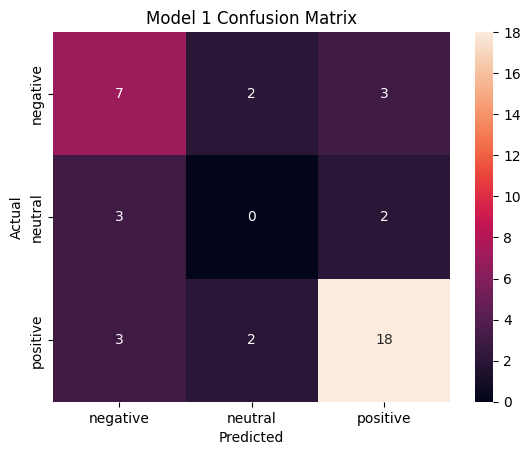

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    df["actual_sentiment"],
    df["model1_prediction"],
    labels=labels
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 1 Confusion Matrix")
plt.show()

In [30]:
errors1 = df[
    df["actual_sentiment"] != df["model1_prediction"]
]

print("Number of errors:", len(errors1))

Number of errors: 15


In [31]:
errors1[
    [
        "text",
        "stars",
        "actual_sentiment",
        "model1_prediction",
        "model1_score"
    ]
].head(10)

,text,stars,actual_sentiment,model1_prediction,model1_score
7,الملغوم الحم مالهم زين,5,positive,negative,0.886269
9,طلبت 4 ملغوم دجاج خلال اقل من دقيقة جابهم لي ا...,2,negative,positive,0.635017
10,جيد بنسبه الى مطاعم الشاورما القريبه له لاكنه ...,2,negative,positive,0.554792
11,شنهو مصادر اللحوم والدجاج هذاي نبي نعرف له,1,negative,neutral,0.736590
17,بهارات شاورما الدجاج كثيرة وشاورما اللحم غير ج...,3,neutral,negative,0.690981
19,✌🏻,5,positive,neutral,0.471113
23,الصراحه عرض يوم الاربعاء خمس وجبات بسعر 66 ريا...,5,positive,neutral,0.684461
27,الي عنده امساك ياكل منهم لأنهم معروفين بهالشي\...,1,negative,positive,0.436319
31,معشوقي والله كل م اشتهيت شاورما ي اروح له ولا ...,5,positive,negative,0.572372
32,Pickup very fast during weekend very crowded.,5,positive,negative,0.669439


## model 2


In [ ]:
pipe2 = pipeline(
    "text-classification",
    model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"
)


In [ ]:
pipe2("الأكل لذيذ والخدمة ممتازة")


In [ ]:
results2 = pipe2(df["text"].tolist())


In [ ]:
for result in results2:
    result["metadata"] = "huggingface_AI_model"

df["model2_prediction"] = [result["label"] for result in results2]
df["model2_score"] = [result["score"] for result in results2]


In [ ]:
accuracy2 = accuracy_score(
    df["actual_sentiment"],
    df["model2_prediction"]
)

print("Model 2 Accuracy:", accuracy2)


In [ ]:
print(classification_report(
    df["actual_sentiment"],
    df["model2_prediction"],
    zero_division=0
))


In [ ]:
cm2 = confusion_matrix(
    df["actual_sentiment"],
    df["model2_prediction"],
    labels=labels
)

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 Confusion Matrix")
plt.show()


In [ ]:
errors2 = df[
    df["actual_sentiment"] != df["model2_prediction"]
]

print("Number of errors:", len(errors2))

errors2[[
    "text",
    "stars",
    "actual_sentiment",
    "model2_prediction",
    "model2_score"
]].head(10)


## model 3


In [ ]:
pipe3 = pipeline(
    "text-classification",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)


In [ ]:
pipe3("The food was amazing and the service was excellent")


In [ ]:
results3 = pipe3(df["text"].tolist())


In [ ]:
for result in results3:
    result["metadata"] = "huggingface_AI_model"

df["model3_prediction"] = [result["label"] for result in results3]
df["model3_score"] = [result["score"] for result in results3]


In [ ]:
accuracy3 = accuracy_score(
    df["actual_sentiment"],
    df["model3_prediction"]
)

print("Model 3 Accuracy:", accuracy3)


In [ ]:
print(classification_report(
    df["actual_sentiment"],
    df["model3_prediction"],
    zero_division=0
))


In [ ]:
cm3 = confusion_matrix(
    df["actual_sentiment"],
    df["model3_prediction"],
    labels=labels
)

sns.heatmap(
    cm3,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 3 Confusion Matrix")
plt.show()


In [ ]:
errors3 = df[
    df["actual_sentiment"] != df["model3_prediction"]
]

print("Number of errors:", len(errors3))

errors3[[
    "text",
    "stars",
    "actual_sentiment",
    "model3_prediction",
    "model3_score"
]].head(10)


## model comparison


In [ ]:
comparison = pd.DataFrame({
    "Model": ["XLM-RoBERTa", "CAMeLBERT", "DistilBERT"],
    "Accuracy": [accuracy1, accuracy2, accuracy3],
    "Errors": [len(errors1), len(errors2), len(errors3)]
})

comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)


## zero shot classification


In [32]:
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [33]:
candidate_labels = [
    "Food Quality",
    "Service",
    "Price",
    "Cleanliness",
    "Atmosphere",
    "Location",
    "Waiting Time"
]

In [34]:
review = "The food was delicious but we waited too long."

result = zero_shot(
    review,
    candidate_labels
)

result

{'sequence': 'The food was delicious but we waited too long.',
 'labels': ['Waiting Time',
  'Food Quality',
  'Price',
  'Service',
  'Location',
  'Atmosphere',
  'Cleanliness'],
 'scores': [0.3889492154121399,
  0.26939135789871216,
  0.10523225367069244,
  0.09164556860923767,
  0.0770183727145195,
  0.04471522942185402,
  0.023047983646392822]}

In [35]:
zero_shot_predictions = []

for text in df["text"]:
    result = zero_shot(
        text,
        candidate_labels
    )

    zero_shot_predictions.append(
        result["labels"][0]
    )

In [36]:
df["zero_shot_prediction"] = zero_shot_predictions

In [37]:
zero_shot_predictions

['Waiting Time',
 'Service',
 'Food Quality',
 'Location',
 'Location',
 'Location',
 'Food Quality',
 'Location',
 'Service',
 'Service',
 'Location',
 'Location',
 'Location',
 'Location',
 'Location',
 'Location',
 'Location',
 'Location',
 'Location',
 'Service',
 'Food Quality',
 'Location',
 'Food Quality',
 'Location',
 'Location',
 'Location',
 'Food Quality',
 'Price',
 'Service',
 'Location',
 'Location',
 'Location',
 'Location',
 'Food Quality',
 'Location',
 'Food Quality',
 'Service',
 'Location',
 'Food Quality',
 'Location']

In [39]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    df["actual_topic"],
    df["zero_shot_prediction"]
)

print("Zero-shot Accuracy:", accuracy)

KeyError: 'actual_topic'

In [ ]:
print(
    classification_report(
        df["actual_topic"],
        df["zero_shot_prediction"]
    )
)